<a href="https://www.kaggle.com/code/abilashkesavan/the-carbon-odyssey-2-0-forecasting-the-future?scriptVersionId=274168228" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-co-emissions/GlobalCO2Emissions.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 🧠 Load + clean
df = pd.read_csv("/kaggle/input/global-co-emissions/GlobalCO2Emissions.csv")
df = df.rename(columns={'Year': 'year', 'Emissions': 'emission'}).dropna()
df['year'] = df['year'].astype(int)
df['emission'] = df['emission'].astype(float)

# ⚡ SQL-style aggregation using pandas (vectorized)
yearly_df = df.groupby('year', observed=True)['emission'].sum().reset_index(name='total_emission')


In [3]:
import sqlite3, pandas as pd
conn = sqlite3.connect(":memory:")
df.to_sql("emissions", conn, index=False, if_exists='replace')
conn.execute("CREATE INDEX idx_year ON emissions(year);")

query = """
SELECT year, SUM(emission) AS total_emission
FROM emissions
GROUP BY year
ORDER BY year;
"""
yearly_df = pd.read_sql_query(query, conn)

In [4]:
# Stack — track growth across years
years = yearly_df['year'].to_numpy()
emissions = yearly_df['total_emission'].to_numpy()
growth = np.diff(emissions, prepend=emissions[0])
stack = list(zip(years, emissions))

# HashMap — instant lookup
year_sum = dict(zip(years, emissions))

# Heap — top emission years
import heapq
heap = [(-v, k) for k, v in year_sum.items()]
heapq.heapify(heap)
top_years = [(k, -v) for v, k in [heapq.heappop(heap) for _ in range(10)]]

print("🔝 Top 10 Emission Years:", top_years)


🔝 Top 10 Emission Years: [(2023, 40.9), (2022, 37.15), (2010, 28.65), (2000, 20.64), (1990, 14.45), (1980, 10.4), (1970, 6.73), (1960, 3.74), (1950, 2.34), (1940, 1.71)]


In [5]:
import time

def stream_and_refit(new_data):
    """
    Real-time stream ingestion + live model retraining
    Simulates Kafka / EventHub real-time data updates
    """
    global df, yearly_df, model

    print("🌐 Streaming in new emission records...\n")

    for record in new_data:
        print(f"Ingesting Year {record['year']} | Emission: {record['emission']:.2f}")
        df.loc[len(df)] = record

        # aggregate new year emission
        yearly_df = df.groupby('year', observed=True)['emission'].sum().reset_index(name='total_emission')

        # 🔁 retrain model live
        X = yearly_df['year'].values.reshape(-1,1)
        y = yearly_df['total_emission'].values
        model.fit(X, y)
        print(f"✅ Model retrained (till {record['year']})")

        time.sleep(0.2)

    print("\n✅ Stream + Refit complete!\n")





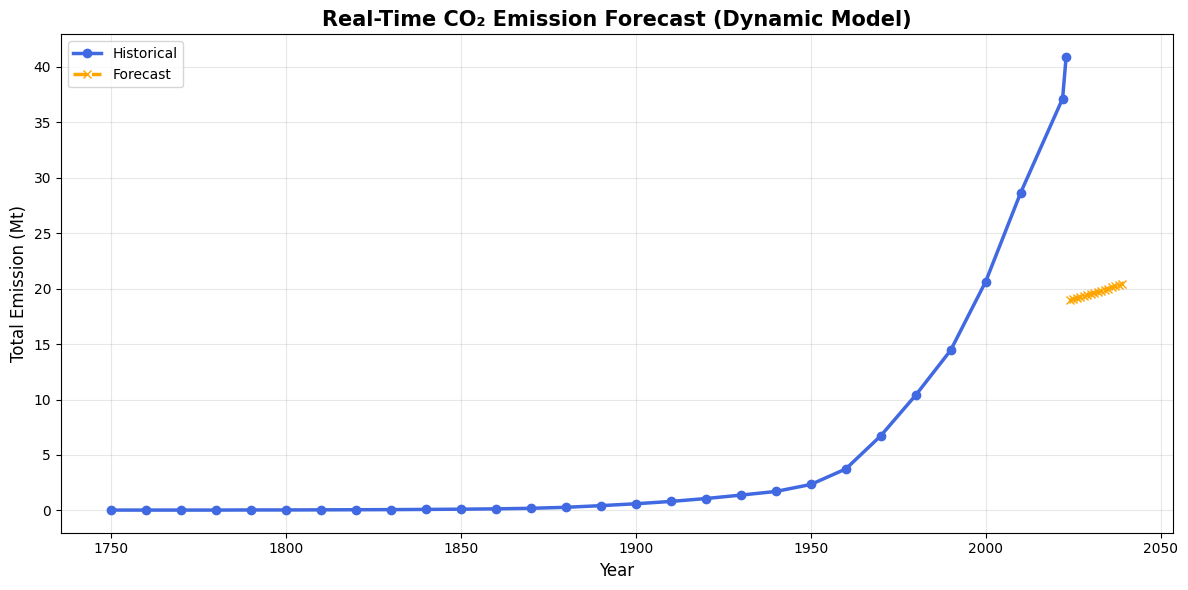

Forecast suggests a -50.13% increase in emissions by 2040 (if current trend continues).


In [6]:
# ===============================
# 🔮 6️⃣ CO₂ Emission Forecasting
# ===============================
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Prepare data for model
# -------------------------------
X = yearly_df[['year']]
y = yearly_df['total_emission']

model = LinearRegression()
model.fit(X, y)

# -------------------------------
# Predict till 2040
# -------------------------------
future_years = np.arange(yearly_df['year'].max() + 1, 2040).reshape(-1, 1)
# Convert to DataFrame with same column name to avoid sklearn warning
future_years_df = pd.DataFrame(future_years, columns=['year'])
predictions = model.predict(future_years_df)

# -------------------------------
# Plot historical + forecast
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(yearly_df['year'], yearly_df['total_emission'], label="Historical",
         color='royalblue', marker='o', linewidth=2.5)
plt.plot(future_years, predictions, '--', label="Forecast",
         color='orange', marker='x', linewidth=2.5)

# Clean title without emojis (avoids missing glyph warnings)
plt.title("Real-Time CO₂ Emission Forecast (Dynamic Model)", fontsize=15, weight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Emission (Mt)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# Print forecast insights
# -------------------------------
growth_rate = (predictions[-1] - y.iloc[-1]) / y.iloc[-1] * 100
print(f"Forecast suggests a {growth_rate:.2f}% increase in emissions by 2040 (if current trend continues).")


In [7]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

def plot_forecast_continuous(df, model):
    # ------------------------
    # Historical data
    # ------------------------
    historical_years = df['year'].values
    historical_emissions = df['total_emission'].values

    # ------------------------
    # Forecast data (start from last historical year)
    # ------------------------
    last_year = df['year'].max()
    future_years = np.arange(last_year, 2040)  # include last historical year for continuity
    future_years_df = pd.DataFrame(future_years, columns=['year'])
    forecast_emissions = model.predict(future_years_df)

    # ------------------------
    # Plot
    # ------------------------
    fig = go.Figure()

    # Continuous line: historical + forecast together
    fig.add_trace(go.Scatter(
        x=np.concatenate([historical_years, future_years[1:]]),  # skip duplicate last_year
        y=np.concatenate([historical_emissions, forecast_emissions[1:]]),
        mode='lines+markers',
        name='Historical + Forecast',
        line=dict(color='royalblue', width=3)
    ))

    # Optional: separate forecast markers for clarity
    fig.add_trace(go.Scatter(
        x=future_years[1:],  # skip last historical year
        y=forecast_emissions[1:],
        mode='markers',
        name='Forecast Points',
        marker=dict(color='orange', size=6, symbol='x')
    ))

    # Layout
    fig.update_layout(
        title="Real-Time Global CO₂ Emission Forecast (Continuous Line)",
        xaxis_title="Year",
        yaxis_title="Total Emission (Mt)",
        template="plotly_white",
        hovermode="x unified",
        width=900,
        height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()


# Visualize continuous forecast
plot_forecast_continuous(yearly_df, model)
